<a href="https://colab.research.google.com/github/Vaishnavi943/Build-ML-Model-from-scratch/blob/main/Building_Logistic_regression_from_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Logistic Regression**

Its a supervised learning model

Classification model

Best for binary classification

Uses Sigmoid function

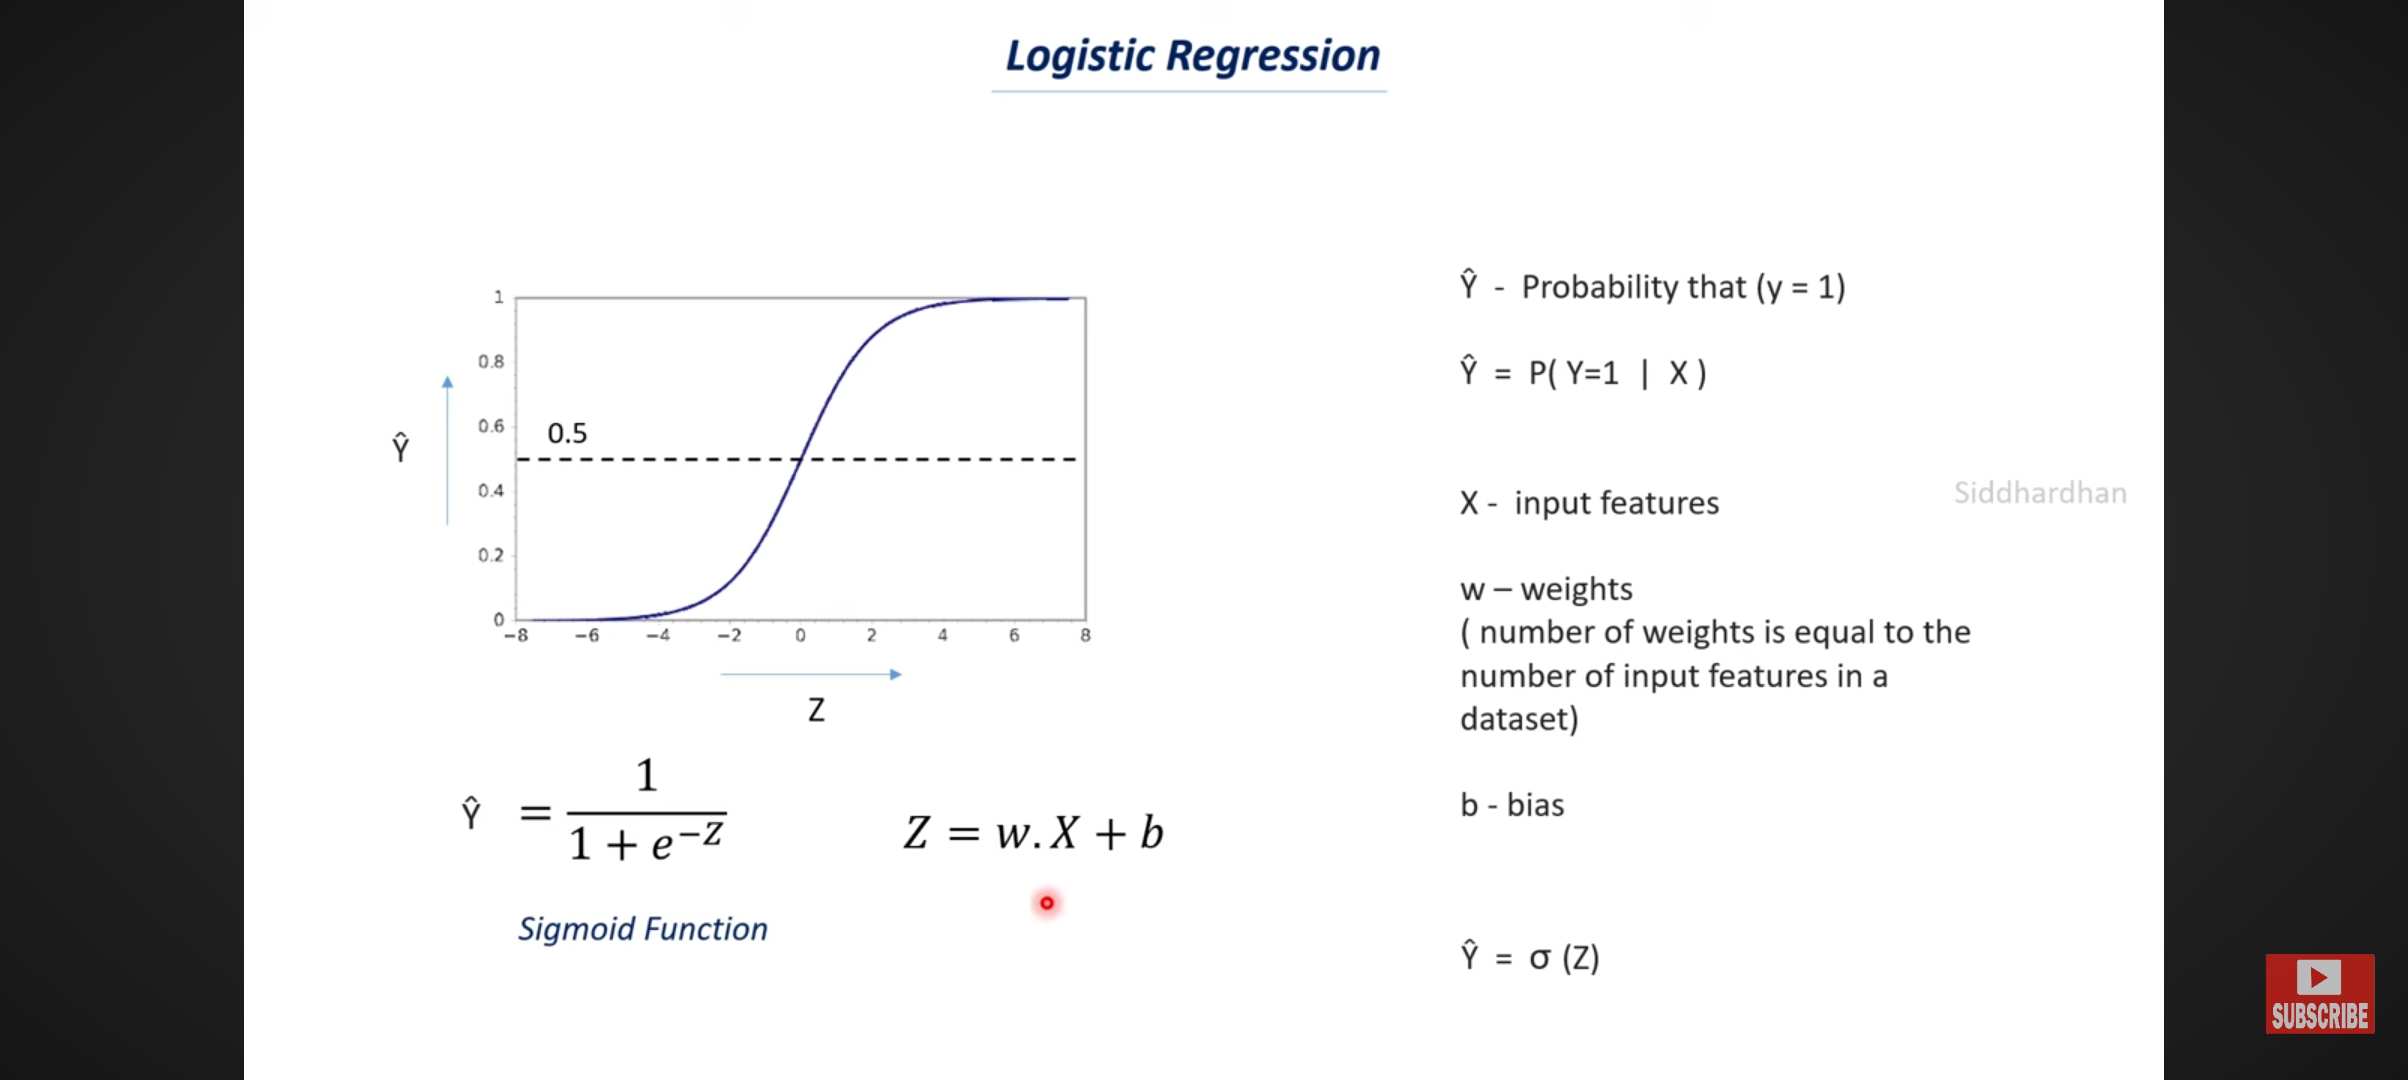

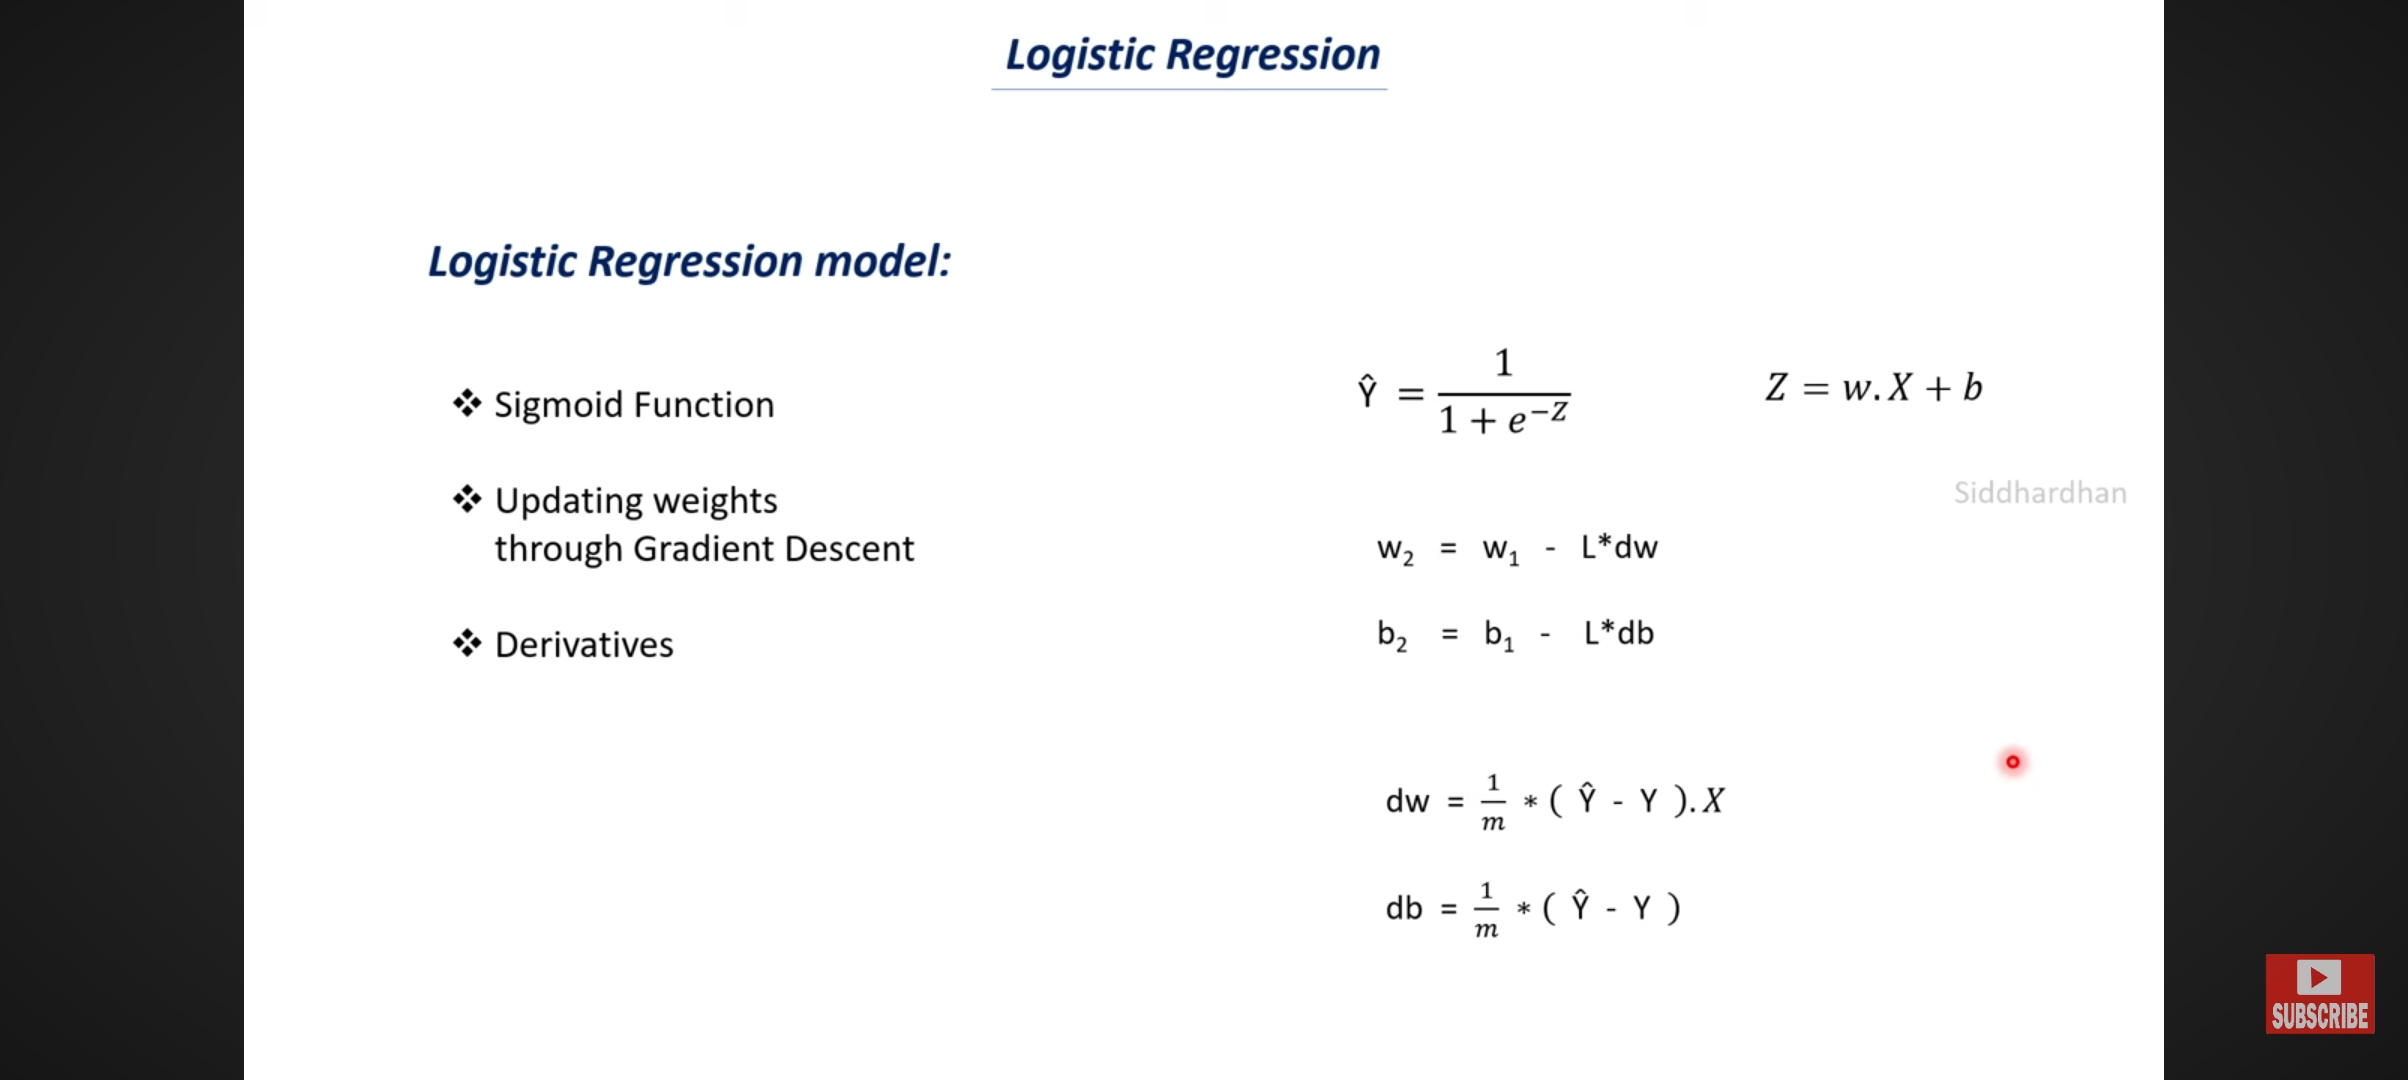

In [112]:
import numpy as np

In [113]:
import numpy as np

class Logistic_Regression:
    def __init__(self, learning_rate, no_of_iteration):
        self.learning_rate = learning_rate
        self.no_of_iteration = no_of_iteration

    def fit(self, x, y):
        # self.m = number of rows, self.n = number of columns
        self.m, self.n = x.shape

        # Initialize weight and bias
        self.w = np.zeros(self.n)
        self.b = 0
        self.x = x
        self.y = y

        # Gradient descent
        for i in range(self.no_of_iteration):
            self.update_weights()

    def update_weights(self):
        # Sigmoid function: y_hat = 1 / (1 + e^-z)
        model_output = self.x.dot(self.w) + self.b
        y_hat = 1 / (1 + np.exp(-model_output))

        # Derivatives
        dw = (1 / self.m) * np.dot(self.x.T, (y_hat - self.y))
        db = (1 / self.m) * np.sum(y_hat - self.y)

        # Update parameters
        self.w = self.w - self.learning_rate * dw
        self.b = self.b - self.learning_rate * db

    def predict(self, x):
        # Use the input x, not the training self.x
        model_output = x.dot(self.w) + self.b
        y_pred = 1 / (1 + np.exp(-model_output))

        # Convert probabilities to classes (0 or 1)
        return np.where(y_pred > 0.5, 1, 0)


In [114]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [115]:
dataset = pd.read_csv('/content/diabetes.csv')

In [116]:
dataset.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [117]:
dataset.shape

(768, 9)

In [118]:
dataset.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [119]:
dataset['Outcome'].value_counts()

,count
Outcome,
0,500
1,268


In [120]:
dataset.groupby('Outcome').mean()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.298000,109.980000,68.184000,19.664000,68.792000,30.304200,0.429734,31.190000
1,4.865672,141.257463,70.824627,22.164179,100.335821,35.142537,0.550500,37.067164


In [121]:
# separating data and label
features = dataset.drop(columns='Outcome', axis=1)
target = dataset['Outcome']

In [122]:
print(features)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  
0                       0.627   50  
1                       0.351   31  


In [123]:
scaler = StandardScaler()

In [124]:
scaler.fit(features)

StandardScaler()

In [125]:
standardized_data = scaler.transform(features)
print(standardized_data)

[[ 0.63994726  0.84832379  0.14964075 ...  0.20401277  0.46849198
   1.4259954 ]
 [-0.84488505 -1.12339636 -0.16054575 ... -0.68442195 -0.36506078
  -0.19067191]
 [ 1.23388019  1.94372388 -0.26394125 ... -1.10325546  0.60439732
  -0.10558415]
 ...
 [ 0.3429808   0.00330087  0.14964075 ... -0.73518964 -0.68519336
  -0.27575966]
 [-0.84488505  0.1597866  -0.47073225 ... -0.24020459 -0.37110101
   1.17073215]
 [-0.84488505 -0.8730192   0.04624525 ... -0.20212881 -0.47378505
  -0.87137393]]


In [126]:
features = standardized_data
target = dataset['Outcome']

print(standardized_data)
print(target)

[[ 0.63994726  0.84832379  0.14964075 ...  0.20401277  0.46849198
   1.4259954 ]
 [-0.84488505 -1.12339636 -0.16054575 ... -0.68442195 -0.36506078
  -0.19067191]
 [ 1.23388019  1.94372388 -0.26394125 ... -1.10325546  0.60439732
  -0.10558415]
 ...
 [ 0.3429808   0.00330087  0.14964075 ... -0.73518964 -0.68519336
  -0.27575966]
 [-0.84488505  0.1597866  -0.47073225 ... -0.24020459 -0.37110101
   1.17073215]
 [-0.84488505 -0.8730192   0.04624525 ... -0.20212881 -0.47378505
  -0.87137393]]
0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64


Train & Test split

In [127]:
x_train, x_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=2)

In [128]:
print(features.shape, x_train.shape, x_test.shape)

(768, 8) (614, 8) (154, 8)


Training the model

In [129]:
classifier = Logistic_Regression(learning_rate=0.01, no_of_iteration=1000)

In [130]:
# training the SVM classifier
classifier.fit(x_train, y_train)

Model evaluation

Accuracy score

In [131]:
# accuracy score on the training data
x_train_prediction = classifier.predict(x_train)
training_data_accuracy = accuracy_score(y_train, x_train_prediction)

In [132]:
print("accuracy score of trainig data is : ", training_data_accuracy)

accuracy score of trainig data is :  0.7768729641693811


In [133]:
# accuracy score on test data
x_test_prediction = classifier.predict(x_test)
test_data_accuracy = accuracy_score(y_test, x_test_prediction)

In [134]:
print("accuracy score of test data is : ", test_data_accuracy)

accuracy score of test data is :  0.7662337662337663


 predictive system

In [136]:
input_data = [5,166,72,19,175,25.8,0.587,51]

# change input data to numpy array
input_data_as_numpy_array = np.asarray(input_data)

# reshape the array as we are predicting for one instance
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)

# standardize the input data
std_data = scaler.transform(input_data_reshaped)
print(std_data)

prediction = classifier.predict(std_data)
print(prediction)

if (prediction[0] == 0):
  print("person is non diabetic")
else:
  print("person is diabetic")


[[ 0.3429808   1.41167241  0.14964075 -0.09637905  0.82661621 -0.78595734
   0.34768723  1.51108316]]
[1]
person is diabetic


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
